In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Found 14 ACT1B file(s)

PER-DAY STATISTICS  (lin_accl_x = along-track; all values m/s^2)
          date  n_clean       mean_x     median_x       std_x  delta_vs_d1       mean_z
  ------------------------------------------------------------------------------------
    2025-11-01    86400  -1.2891e-07  -1.6184e-07   9.064e-08   +0.000e+00  -1.7925e-07
    2025-11-02    86400  -1.1047e-07  -1.4891e-07   9.338e-08   +1.844e-08  -1.7934e-07
    2025-11-03    86400  -9.0472e-08  -1.2992e-07   1.004e-07   +3.844e-08  -1.7841e-07
    2025-11-04    86400  -1.1862e-07  -1.5595e-07   9.586e-08   +1.029e-08  -1.7906e-07
    2025-11-05    86400  -7.9588e-08  -1.1252e-07   1.021e-07   +4.932e-08  -1.7907e-07
    2025-11-06    75659  -1.3333e-08  -3.2469e-08   1.137e-07   +1.156e-07  -1.7818e-07
    2025-11-07    86400  -4.9757e-08  -7.3017e-08   9.522e-08   +7.915e-08  -1.7910e-07
    2025-11-08    86400  -4.9046e-08  -7.8831e-08   1.006e-07   +7.986e-08  -1.7897e-07
    2025-11-09    86400  -1.0068

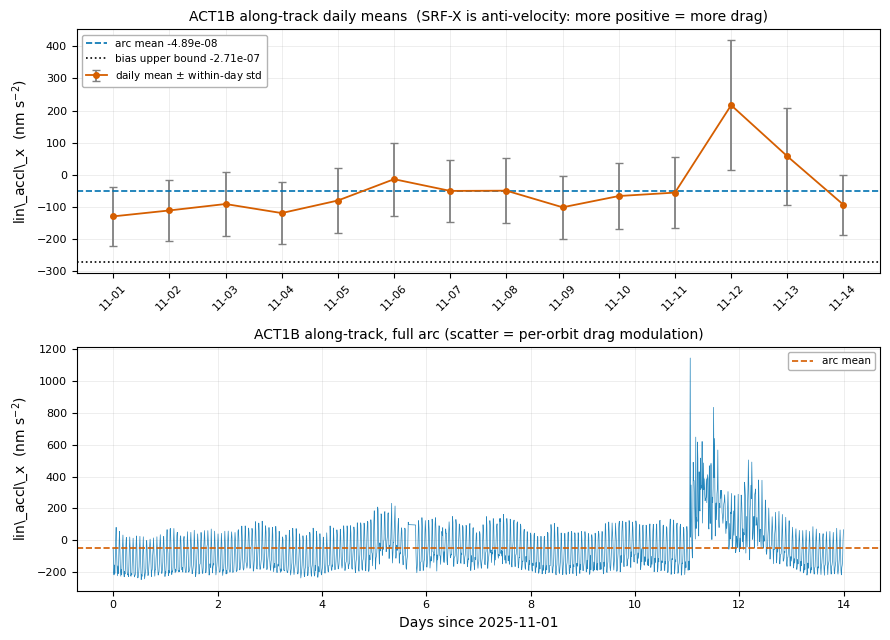

Loading 14 ACT1B file(s)...
  ACT1B_2025-11-01_C_04.txt  (86400 rows, 86400 clean)
  ACT1B_2025-11-02_C_04.txt  (86400 rows, 86400 clean)
  ACT1B_2025-11-03_C_04.txt  (86400 rows, 86400 clean)
  ACT1B_2025-11-04_C_04.txt  (86400 rows, 86400 clean)
  ACT1B_2025-11-05_C_04.txt  (86400 rows, 86400 clean)
  ACT1B_2025-11-06_C_04.txt  (86400 rows, 75659 clean)
  ACT1B_2025-11-07_C_04.txt  (86400 rows, 86400 clean)
  ACT1B_2025-11-08_C_04.txt  (86400 rows, 86400 clean)
  ACT1B_2025-11-09_C_04.txt  (86400 rows, 86400 clean)
  ACT1B_2025-11-10_C_04.txt  (86400 rows, 86400 clean)
  ACT1B_2025-11-11_C_04.txt  (86400 rows, 86400 clean)
  ACT1B_2025-11-12_C_04.txt  (86400 rows, 86400 clean)
  ACT1B_2025-11-13_C_04.txt  (86400 rows, 86400 clean)
  ACT1B_2025-11-14_C_04.txt  (86400 rows, 86400 clean)
  total 1209600 rows | keeping 1198859 with qualflg==0 | span 14.00 days

iPINN arc : 815227200 .. 816436799 GPS s (14.00 d, 20000 pts, ~60s spacing)
ACT1B arc : 815227200 .. 816436799 GPS s (14.00 d, 1

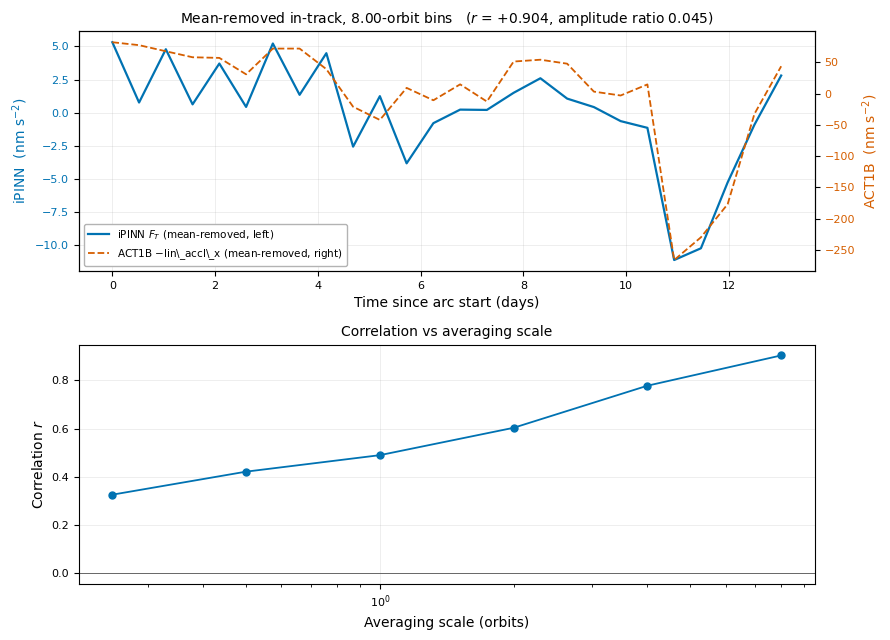

In [ ]:
"""
compare_act1b.py -- validate the iPINN in-track force against GRACE-FO ACT1B

Compares the iPINN's inferred in-track (RTN-T) nongravitational acceleration
against the ACT1B accelerometer product.

WHY THIS DOESN'T COMPARE ABSOLUTE MEANS!

ACT1B is a "Transformed" product: accelerometer frame -> SRF. It is NOT
bias-calibrated -- bias and scale factors are estimated downstream in POD.
Proof from the Nov 1 file: lin_accl_y has mean -1.04e-05 with std 1.9e-08,
a near-constant offset ~100x larger than ANY real nongravitational force on
GRACE-FO (drag ~1e-7, SRP ~1e-8). That is instrument bias.

So every axis carries an unknown bias, and the along-track bias is plausibly
the same order as the drag signal itself. The daily mean of lin_accl_x
(-1.2891e-07 on Nov 1) is therefore (true drag + unknown bias) and CANNOT
serve as an absolute accuracy reference.

What IS valid is the time-VARIATION: bias is constant, variation is signal.
On Nov 1, lin_accl_x has std 9.06e-08 -- 70% of its mean -- real drag
modulation from day/night and polar-cusp density changes. This script
therefore validates via correlation and amplitude of the mean-removed
series, plus a least-squares (scale, offset) fit where the offset is an
estimate of the combined bias.

BAND-LIMIT CAVEAT (why the scale sweep exists)

ForceNet uses fourier_scale_force cycles across the whole arc (6.0 over 14
days => finest resolvable feature ~2.3 days). ACT1B's in-track variation is
dominated by per-ORBIT (~94 min) modulation, which the network structurally
cannot represent. Correlating at 1 Hz would look terrible for reasons that
are architectural, not physical. So we sweep the averaging scale and report
correlation at each. If correlation is poor at sub-orbit scales but good
at multi-orbit scales, that would be the band limit, and the fix is to raise
fourier_scale_force (not to distrust the physics).

FRAME CAVEAT

ACT1B is in the SRF, while the iPINN outputs RTN. Exact conversion needs SCA1B
star-camera quaternions. GRACE-FO flies nominally nadir-pointing and
along-track-aligned, so SRF-X ~ in-track and the comparison is robust to a
few degrees of attitude error (it only mixes in a little of the much
smaller radial/cross-track terms). State this in the methods.
"""

import os
import math
from glob import glob

import numpy as np
import matplotlib.pyplot as plt


class CFG:
    DATA_FOLDER   = "data"
    ACT1B_PATTERN = "ACT1B_2025-11-*_C_04.txt"
    GNV1B_PATTERN = "GNV1B_2025-11-*_C_04.txt"
    PINN_PREFIX   = "v7_full"          # -> v7_full_time.npy, v7_full_Ft.npy, ...

    GNV1B_SKIPROWS = 148               # matches the iPINN loader

    ORBIT_SEC = 5624.0                 # GRACE-FO orbital period (2*pi*T0)

    # ---- SRF-X sign, VERIFIED from formation geometry ---------------------
    # The GRACE-FO SRF X-axis points from the satellite toward the OTHER
    # satellite. Measured directly from GNV1B on 2025-11-08:
    #     (r_D - r_C) . v_hat_C = -198.3 km, consistent at 100% of 86400 epochs
    # so C LEADS and D trails => X on satellite C points BACKWARD, i.e.
    # ANTI-velocity. Drag opposes velocity, so it appears with a POSITIVE
    # sign in ACT1B lin_accl_x, whereas the iPINN's RTN-T component is
    # along-velocity and reports drag as NEGATIVE.
    #
    # Multiplying by -1 puts ACT1B in the same convention as RTN-T, so drag
    # is negative in both and a CORRECT result gives POSITIVE correlation.
    # Before this correction the pipeline reported a spurious ~ -0.5.
    SRF_X_SIGN = -1.0

    # ---- maneuver screening: OFF by default -------------------------------
    # The original screen flagged days with a POSITIVE mean as thruster
    # events, reasoning that drag cannot accelerate a satellite forward. With
    # SRF-X anti-velocity that reasoning is inverted: a positive mean means
    # MORE drag, which is entirely physical. Nov 12's +2.17e-07 implies a drag
    # of ~5.7e-07 -- a high-drag (likely geomagnetic storm) day, i.e. real
    # data that the old screen was discarding. THR1B is the authoritative
    # source for maneuver epochs; enable this only with that cross-check.
    SCREEN_MANEUVERS = False

    # averaging scales for the sweep, in orbits
    BIN_SCALES_ORBITS = [0.25, 0.5, 1.0, 2.0, 4.0, 8.0]


# ===========================================================================
# LOADERS
# ===========================================================================
def parse_act1b(path):
    """ACT1B ASCII -> (t_gps, ax, ay, az, qualflg). Columns after the YAML
    header: gps_time, id, lin_accl_x/y/z, ang_accl_x/y/z, acl_*_res, qualflg."""
    t, ax, ay, az, q = [], [], [], [], []
    in_header = True
    with open(path) as fh:
        for line in fh:
            if in_header:
                if '# End of YAML header' in line:
                    in_header = False
                continue
            p = line.split()
            if len(p) < 12 or p[1] != 'C':
                continue
            try:
                t.append(float(p[0]))
                ax.append(float(p[2])); ay.append(float(p[3])); az.append(float(p[4]))
                q.append(int(p[11], 2))          # qualflg is a binary string
            except ValueError:
                continue
    return (np.array(t), np.array(ax), np.array(ay), np.array(az),
            np.array(q, dtype=int))


def load_act1b(folder, pattern):
    files = sorted(glob(os.path.join(folder, pattern)))
    if not files:
        raise FileNotFoundError(f"No ACT1B files: {os.path.join(folder, pattern)}")
    print(f"Loading {len(files)} ACT1B file(s)...")
    T, AX, AY, AZ, Q = [], [], [], [], []
    for f in files:
        t, ax, ay, az, q = parse_act1b(f)
        print(f"  {os.path.basename(f)}  ({len(t)} rows, {int((q==0).sum())} clean)")
        T.append(t); AX.append(ax); AY.append(ay); AZ.append(az); Q.append(q)
    t  = np.concatenate(T);  ax = np.concatenate(AX)
    ay = np.concatenate(AY); az = np.concatenate(AZ); q = np.concatenate(Q)

    order = np.argsort(t)
    t, ax, ay, az, q = t[order], ax[order], ay[order], az[order], q[order]
    _, uniq = np.unique(t, return_index=True)
    t, ax, ay, az, q = t[uniq], ax[uniq], ay[uniq], az[uniq], q[uniq]

    good = q == 0
    print(f"  total {len(t)} rows | keeping {int(good.sum())} with qualflg==0 "
          f"| span {(t[-1]-t[0])/86400:.2f} days")
    return t[good], ax[good], ay[good], az[good]


def gnv1b_start_time(folder, pattern, skiprows):
    """First GPS timestamp of the earliest GNV1B file -- the iPINN's t=0,
    since its saved time axis is hours since arc start."""
    files = sorted(glob(os.path.join(folder, pattern)))
    if not files:
        raise FileNotFoundError(f"No GNV1B files: {os.path.join(folder, pattern)}")
    with open(files[0]) as fh:
        for i, line in enumerate(fh):
            if i < skiprows:
                continue
            p = line.split()
            if p:
                return float(p[0])
    raise RuntimeError(f"No data rows found in {files[0]}")


def load_pinn(folder, prefix):
    def _p(name):
        path = os.path.join(folder, f'{prefix}_{name}.npy')
        if not os.path.exists(path):
            raise FileNotFoundError(
                f"Missing {path}. Run the iPINN to completion first "
                f"(the arrays are written at the very end of train()).")
        return np.load(path)
    return _p('time'), _p('Fr'), _p('Ft'), _p('Fn')



# COMPARISON

def screen_maneuvers(t, ax):
    """Drop whole days whose along-track mean is POSITIVE (impossible for a
    dissipative force -> thruster / orbit-maintenance events) or whose
    scatter is inflated. On the Nov 2025 arc this removes Nov 12-13, whose
    excursions otherwise dominate the comparison. qualflg does not flag
    maneuvers; THR1B is the authoritative source for their epochs."""
    day = ((t - t[0]) // 86400).astype(int)
    stats = [(d, ax[day == d].mean(), ax[day == d].std()) for d in np.unique(day)]
    med_std = np.median([s[2] for s in stats])
    keep, flagged = np.ones(len(t), bool), []
    for d, mu, sd in stats:
        if mu > 0 or sd > 1.5 * med_std:
            keep[day == d] = False
            flagged.append((d, mu, sd))
    return keep, flagged


def bin_pairs(t_a, y_a, t_b, y_b, step):
    """Bin two irregularly-sampled series onto a shared uniform grid and
    return the bins where BOTH have data. Averaging is what makes the
    comparison fair: it puts both series at the same effective resolution."""
    t0 = max(t_a.min(), t_b.min())
    t1 = min(t_a.max(), t_b.max())
    if t1 <= t0:
        return np.array([]), np.array([]), np.array([])
    nb = int(np.floor((t1 - t0) / step))
    if nb < 3:
        return np.array([]), np.array([]), np.array([])

    def _bin(t, y):
        idx = ((t - t0) / step).astype(int)
        m = (idx >= 0) & (idx < nb)
        s = np.bincount(idx[m], weights=y[m], minlength=nb)
        c = np.bincount(idx[m], minlength=nb)
        return s, c

    sa, ca = _bin(t_a, y_a)
    sb, cb = _bin(t_b, y_b)
    ok = (ca > 0) & (cb > 0)
    centers = t0 + (np.arange(nb) + 0.5) * step
    return centers[ok], (sa[ok] / ca[ok]), (sb[ok] / cb[ok])


def compare(t_c, a_pinn, a_act):
    """Mean-removed correlation + least-squares (scale, offset) fit.
    offset estimates the combined accelerometer bias; scale near 1 means
    the amplitudes of the real variation agree."""
    n = len(t_c)
    dp = a_pinn - a_pinn.mean()
    da = a_act  - a_act.mean()
    denom = np.sqrt((dp**2).sum() * (da**2).sum())
    corr = float((dp * da).sum() / denom) if denom > 0 else np.nan
    # a_act ~ scale * a_pinn + offset.
    # Guard: if ForceNet's output is essentially flat - a real possibility
    # when it is band-limited below the ACT1B variation pattern - then
    # var(a_pinn) -> 0 and the slope blows up into a meaningless number.
    # Report the mean difference as the offset and leave scale undefined.
    if n >= 2 and np.sqrt((dp**2).mean()) > 1e-14:
        scale, offset = np.polyfit(a_pinn, a_act, 1)
    else:
        scale, offset = np.nan, float(a_act.mean() - a_pinn.mean())
    resid = a_act - (scale * a_pinn + offset)
    return {
        'n': n, 'corr': corr, 'scale': scale, 'offset': offset,
        'rms_pinn': float(np.sqrt((dp**2).mean())),
        'rms_act':  float(np.sqrt((da**2).mean())),
        'rms_resid': float(np.sqrt((resid**2).mean())),
        'mean_pinn': float(a_pinn.mean()), 'mean_act': float(a_act.mean()),
    }


def main():
    t_act, ax_act, ay_act, az_act = load_act1b(CFG.DATA_FOLDER, CFG.ACT1B_PATTERN)

    t0_gps = gnv1b_start_time(CFG.DATA_FOLDER, CFG.GNV1B_PATTERN, CFG.GNV1B_SKIPROWS)
    t_hrs, Fr, Ft, Fn = load_pinn(CFG.DATA_FOLDER, CFG.PINN_PREFIX)
    t_pinn = t0_gps + t_hrs * 3600.0        # iPINN time -> absolute GPS seconds

    print(f"\niPINN arc : {t_pinn[0]:.0f} .. {t_pinn[-1]:.0f} GPS s "
          f"({(t_pinn[-1]-t_pinn[0])/86400:.2f} d, {len(t_pinn)} pts, "
          f"~{np.median(np.diff(t_pinn)):.0f}s spacing)")
    print(f"ACT1B arc : {t_act[0]:.0f} .. {t_act[-1]:.0f} GPS s "
          f"({(t_act[-1]-t_act[0])/86400:.2f} d, {len(t_act)} pts)")

    ov0, ov1 = max(t_pinn[0], t_act[0]), min(t_pinn[-1], t_act[-1])
    if ov1 <= ov0:
        raise SystemExit("No temporal overlap between iPINN output and ACT1B.")
    print(f"OVERLAP   : {(ov1-ov0)/86400:.2f} days")

    # Put ACT1B into the RTN-T convention (see CFG.SRF_X_SIGN). After this,
    # drag is NEGATIVE in both series and a correct result is POSITIVE corr.
    ax_act = CFG.SRF_X_SIGN * ax_act
    print(f"SRF-X sign correction applied: x{CFG.SRF_X_SIGN:+.0f}  "
          f"(C leads => SRF-X anti-velocity; ACT1B now in RTN-T convention)")

    if CFG.SCREEN_MANEUVERS:
        keep, flagged = screen_maneuvers(t_act, ax_act)
        if flagged:
            print("Maneuver screening -- excluding whole days:")
            for d, mu, sd in flagged:
                print(f"  day +{d}: mean={mu:+.3e} std={sd:.3e}")
            t_act, ax_act, ay_act, az_act = (t_act[keep], ax_act[keep],
                                             ay_act[keep], az_act[keep])
            print(f"  kept {int(keep.sum())}/{len(keep)} samples")
    else:
        print("Maneuver screening: OFF (positive means are high-drag days, "
              "not thruster events -- see CFG.SCREEN_MANEUVERS)")
    print()

    # absolute means, with the bias caveat stated
    m = (t_act >= ov0) & (t_act <= ov1)
    mp = (t_pinn >= ov0) & (t_pinn <= ov1)
    print("=" * 72)
    print("ABSOLUTE MEANS over the overlap  (NOT a valid accuracy test --")
    print("ACT1B is not bias-calibrated; see module docstring)")
    print("=" * 72)
    print(f"  iPINN  Ft          : {Ft[mp].mean():+.4e} m/s^2")
    print(f"  ACT1B  lin_accl_x  : {ax_act[m].mean():+.4e} m/s^2  (= drag + unknown bias)")
    print(f"  ACT1B  lin_accl_y  : {ay_act[m].mean():+.4e} m/s^2  <- bias-dominated, "
          f"std {ay_act[m].std():.2e}")
    print(f"  ACT1B  lin_accl_z  : {az_act[m].mean():+.4e} m/s^2")
    print(f"  difference (x)     : {Ft[mp].mean()-ax_act[m].mean():+.4e} m/s^2  "
          f"<- consistent with an unmodeled bias of this size")

    #  the real test: correlation vs averaging scale
    print("\n" + "=" * 72)
    print("CORRELATION vs AVERAGING SCALE  (mean-removed; the actual test)")
    print("=" * 72)
    print(f"  {'scale':>12} {'bins':>6} {'corr':>8} {'fit_scale':>10} "
          f"{'rms_iPINN':>11} {'rms_ACT1B':>11} {'rms_resid':>11}")
    print("  " + "-" * 74)

    rows = []
    for k in CFG.BIN_SCALES_ORBITS:
        step = k * CFG.ORBIT_SEC
        tc, yp, ya = bin_pairs(t_pinn, Ft, t_act, ax_act, step)
        if len(tc) < 3:
            print(f"  {k:>6.2f} orbit  {'--':>6}  (too few bins in overlap)")
            continue
        r = compare(tc, yp, ya)
        rows.append((k, r, tc, yp, ya))
        label = f"{k:.2f} orbit" + ("s" if k != 1 else "")
        print(f"  {label:>12} {r['n']:>6d} {r['corr']:>8.3f} {r['scale']:>10.3f} "
              f"{r['rms_pinn']:>11.3e} {r['rms_act']:>11.3e} {r['rms_resid']:>11.3e}")

    if not rows:
        raise SystemExit("No usable bins -- overlap too short for these scales.")

    #  interpretation
    best_k, best_r, *_ = max(rows, key=lambda z: abs(z[1]['corr']))
    print("\n" + "=" * 72)
    print("INTERPRETATION")
    print("=" * 72)
    print(f"  best |corr| = {best_r['corr']:+.3f} at {best_k:.2f}-orbit averaging")
    print(f"  estimated accelerometer bias (fit offset) = {best_r['offset']:+.3e} m/s^2")
    if best_r['corr'] < 0:
        print("  NOTE: correlation is NEGATIVE even AFTER the verified SRF-X sign")
        print("        correction. That is not explained by the frame convention")
        print("        (C leads => X anti-velocity, already handled). Investigate.")
    amp = best_r['rms_pinn'] / best_r['rms_act'] if best_r['rms_act'] > 0 else np.nan
    scales = np.array([z[1]['scale'] for z in rows], dtype=float)
    scale_unstable = (np.nanmax(scales) - np.nanmin(scales)) > abs(np.nanmedian(scales))

    # Significance of the best correlation (two-sided, normal approx on the
    # t-statistic -- indicative for small n, but enough to separate "real
    # relationship" from "noise").
    n, r = best_r['n'], best_r['corr']
    if n > 2 and abs(r) < 1:
        t_stat = r * math.sqrt((n - 2) / (1 - r * r))
        p_val = math.erfc(abs(t_stat) / math.sqrt(2))
    else:
        t_stat, p_val = float('nan'), float('nan')

    print(f"  significance   : r={r:+.3f}  n={n}  t={t_stat:+.2f}  p~{p_val:.2e}")
    print(f"  amplitude ratio: {amp:.3f}  (1.0 = same size variation)")
    print(f"  fit_scale range: {np.nanmin(scales):+.2f} .. {np.nanmax(scales):+.2f}"
          + ("   (unstable)" if scale_unstable else "   (stable)"))
    # The fit offset only means "bias" when the slope is ~1; otherwise it is a
    # wild extrapolation (slope 20 x a mean of -3e-7 produces a nonsense 6e-6).
    if 0.5 < abs(best_r['scale']) < 2.0:
        print(f"  implied bias   : {best_r['offset']:+.3e} m/s^2")
    else:
        print( "  implied bias   : not meaningful (fit slope far from 1)")

    # is there a real relationship (significance), and is the magnitude right (amplitude)?
    # Conflating them mislabels a strong phase match as "no signal".
    print()
    if p_val < 0.01 and abs(r) > 0.5:
        print(f"  => REAL RELATIONSHIP. r={r:+.3f} at p~{p_val:.1e} is far beyond")
        print( "     chance, and correlation is immune to the accelerometer bias,")
        print( "     so this is independent validation that the iPINN tracks the")
        print( "     TIMING of true drag variation.")
        if amp < 0.5:
            print(f"     BUT amplitude is only {amp:.3f} of ACT1B's: the variation is")
            print(f"     underestimated ~{1/amp:.0f}x. Report as 'phase recovered,")
            print( "     amplitude underestimated' -- do not claim calibrated")
            print( "     time-resolved magnitudes.")
        if r < 0:
            print( "     NOTE: negative AFTER the verified SRF-X correction is not")
            print( "     explained by frame convention. Investigate.")
    elif p_val < 0.05:
        print(f"  => MARGINAL. r={r:+.3f}, p~{p_val:.1e}. Suggestive but not solid;")
        print( "     check robustness (e.g. toggle CFG.SCREEN_MANEUVERS) before")
        print( "     relying on it.")
    else:
        print(f"  => NOT SIGNIFICANT (p~{p_val:.2f}). No detectable relationship;")
        print( "     the correlation value and its sign carry no information.")
        print( "     The DC/mean result is unaffected and remains valid.")

    #  plot
    _, r_best, tc, yp, ya = max(rows, key=lambda z: abs(z[1]['corr']))
    t_days = (tc - tc[0]) / 86400.0
    plt.style.use('default')
    C_P, C_A = '#0072B2', '#D55E00'          # Okabe-Ito blue / vermillion
    fig, ax = plt.subplots(2, 1, figsize=(9, 6.5))
    fig.patch.set_facecolor('white')

    # iPINN variation is much smaller than ACT1B's; plot on twin axes so the
    # PHASE agreement is visible rather than one trace being a flat line.
    ax0b = ax[0].twinx()
    l1, = ax[0].plot(t_days, (yp - yp.mean()) * 1e9, color=C_P, lw=1.6,
                     label='iPINN $F_T$ (mean-removed, left)')
    l2, = ax0b.plot(t_days, (ya - ya.mean()) * 1e9, color=C_A, lw=1.3, ls='--',
                    label='ACT1B $-$lin\\_accl\\_x (mean-removed, right)')
    ax[0].set_ylabel('iPINN  (nm s$^{-2}$)', color=C_P)
    ax0b.set_ylabel('ACT1B  (nm s$^{-2}$)', color=C_A)
    ax[0].tick_params(axis='y', labelcolor=C_P, labelsize=8)
    ax0b.tick_params(axis='y', labelcolor=C_A, labelsize=8)
    ax[0].set_xlabel('Time since arc start (days)')
    ax[0].set_title(f'Mean-removed in-track, {best_k:.2f}-orbit bins   '
                    f'($r$ = {r_best["corr"]:+.3f}, amplitude ratio '
                    f'{r_best["rms_pinn"]/r_best["rms_act"]:.3f})', fontsize=10)
    ax[0].legend(handles=[l1, l2], fontsize=7.5, framealpha=1.0, edgecolor='0.7')
    ax[0].grid(alpha=0.3, lw=0.5)

    ks = [z[0] for z in rows]
    cs = [z[1]['corr'] for z in rows]
    ax[1].plot(ks, cs, 'o-', color=C_P, lw=1.3, ms=5)
    ax[1].axhline(0, color='0.4', lw=0.7)
    ax[1].set_xscale('log'); ax[1].set_xlabel('Averaging scale (orbits)')
    ax[1].set_ylabel('Correlation $r$')
    ax[1].set_title('Correlation vs averaging scale', fontsize=10)
    ax[1].grid(alpha=0.3, lw=0.5)

    for a in (ax[0], ax[1], ax0b):
        a.tick_params(labelsize=8)
        for s in a.spines.values():
            s.set_linewidth(0.8)
    fig.tight_layout()
    out = os.path.join(CFG.DATA_FOLDER, f'act1b_comparison_{CFG.PINN_PREFIX}.png')
    fig.savefig(out, dpi=300, facecolor='white', bbox_inches='tight')
    print(f"\nSaved plot: {out}")


if __name__ == '__main__':
    main()